# Stress Testing de Cartera Crediticia
**Modelo:** Transformación logit sobre PD base con shocks macroeconómicos  
**Variables:** Variación PBI + Tasa de desempleo  
**Output:** PD estresada, Pérdida Esperada (EL = PD × LGD × EAD), análisis de concentración y sensibilidad

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

## 1. Carga y validación de datos

In [2]:
df = pd.read_csv('pd_stress_testing.csv', index_col=False)
df = df.drop('Unnamed: 0', axis=1)
df.head(10)

,PD,saldo_actual,limite,LGD,EAD,EL
0,0.707421,19352,9909,0.45,19352.00,6160.502173
1,0.547952,47585,55478,0.45,53504.75,13193.122767
2,0.765016,36867,56360,0.45,51486.75,17724.684390
3,0.502764,30334,65555,0.45,56749.75,12839.276134
4,0.376505,8644,73978,0.45,57644.50,9766.561029
5,0.590395,8643,97705,0.45,75439.50,20042.585483
6,0.407281,3846,54048,0.45,41497.50,7605.520498
7,0.297484,43442,35680,0.45,43442.00,5815.493906
8,0.755605,30454,80542,0.45,68020.00,23128.320381
9,0.485318,35695,30729,0.45,35695.00,7795.533729


In [3]:
print('=== Tipos de datos ===')
print(df.dtypes)
print('\n=== Nulos ===')
print(df.isnull().sum())

=== Tipos de datos ===
PD              float64
saldo_actual      int64
limite            int64
LGD             float64
EAD             float64
EL              float64
dtype: object

=== Nulos ===
PD              0
saldo_actual    0
limite          0
LGD             0
EAD             0
EL              0
dtype: int64


In [4]:
# Validaciones de dominio — falla rápido si los datos están mal
assert df['PD'].between(0, 1).all(),  "PD fuera de rango [0,1]"
assert df['LGD'].between(0, 1).all(), "LGD fuera de rango [0,1]"
assert (df['EAD'] > 0).all(),         "EAD con valores negativos o cero"
print("Validaciones de dominio OK")
print(f"Cartera: {len(df):,} clientes | EAD total: ${df['EAD'].sum():,.0f}")

Validaciones de dominio OK
Cartera: 300 clientes | EAD total: $14,813,173


## 2. EDA

In [5]:
df[['PD', 'LGD', 'EAD']].describe().round(4)

,PD,LGD,EAD
count,300.0000,300.00,300.0000
mean,0.5450,0.45,49377.2442
std,0.1878,0.00,18959.6499
min,0.1264,0.45,5822.0000
25%,0.4067,0.45,36742.7500
50%,0.5483,0.45,48350.3750
75%,0.6805,0.45,65891.3750
max,0.9174,0.45,84537.0000


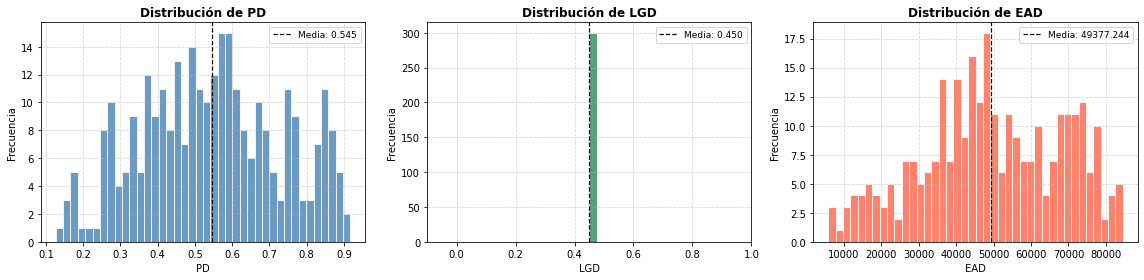

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
vars_eda = ['PD', 'LGD', 'EAD']
colors   = ['steelblue', 'seagreen', 'tomato']

for ax, var, color in zip(axes, vars_eda, colors):
    ax.hist(df[var], bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(df[var].mean(), color='black', linestyle='--', linewidth=1.2,
               label=f'Media: {df[var].mean():.3f}')
    ax.set_title(f'Distribución de {var}', fontweight='bold')
    ax.set_xlabel(var)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 3. Modelo logit y escenarios

In [7]:
# Escenarios macroeconómicos
# Desempleo base INDEC ~7%, PBI crecimiento tendencial ~2.5%
escenarios = {
    'Base':    {'pbi_var':  0.025, 'desempleo': 0.07},
    'Adverso': {'pbi_var': -0.015, 'desempleo': 0.10},
    'Severo':  {'pbi_var': -0.05,  'desempleo': 0.14}
}

In [8]:
def calcular_pd_estresada(PD, pbi_var, desempleo_actual, desempleo_base=0.07):
    """
    Aplica shocks macroeconómicos a la PD base mediante transformación logit.

    Betas (calibrar con serie histórica propia):
      beta_pbi       = -2.5  → caída PBI sube PD
      beta_desempleo =  3.0  → más desempleo sube PD
    """
    PD = np.clip(PD, 0.0001, 0.9999)
    logit_base = np.log(PD / (1 - PD))

    beta_pbi       = -2.5
    beta_desempleo =  3.0

    logit_stress = (logit_base
                    + beta_pbi       * pbi_var
                    + beta_desempleo * (desempleo_actual - desempleo_base))

    return 1 / (1 + np.exp(-logit_stress))

In [9]:
for esc, vars_ in escenarios.items():
    df[f'PD_{esc}'] = calcular_pd_estresada(
        df['PD'], vars_['pbi_var'], vars_['desempleo']
    )
    df[f'EL_{esc}'] = df[f'PD_{esc}'] * df['LGD'] * df['EAD']

## 4. Resumen de impacto en la cartera

In [10]:
el_base  = df['EL_Base'].sum()
ead_total = df['EAD'].sum()

resumen = pd.DataFrame({
    'Escenario': ['Base', 'Adverso', 'Severo'],
    'PD Promedio (%)': [
        df['PD_Base'].mean()    * 100,
        df['PD_Adverso'].mean() * 100,
        df['PD_Severo'].mean()  * 100
    ],
    'EL Total ($)': [
        df['EL_Base'].sum(),
        df['EL_Adverso'].sum(),
        df['EL_Severo'].sum()
    ],
    'Incremento vs Base (%)': [
        0.0,
        (df['EL_Adverso'].sum() / el_base - 1) * 100,
        (df['EL_Severo'].sum()  / el_base - 1) * 100
    ],
    'EL / EAD (%)': [
        df['EL_Base'].sum()    / ead_total * 100,
        df['EL_Adverso'].sum() / ead_total * 100,
        df['EL_Severo'].sum()  / ead_total * 100
    ]
})
resumen.set_index('Escenario')

,PD Promedio (%),EL Total ($),Incremento vs Base (%),EL / EAD (%)
Escenario,,,,
Base,53.163349,3.509516e+06,0.000000,23.691859
Adverso,57.196915,3.778792e+06,7.672736,25.509672
Severo,61.512507,4.067449e+06,15.897728,27.458326


## 5. Distribución de la Pérdida Esperada (KDE)

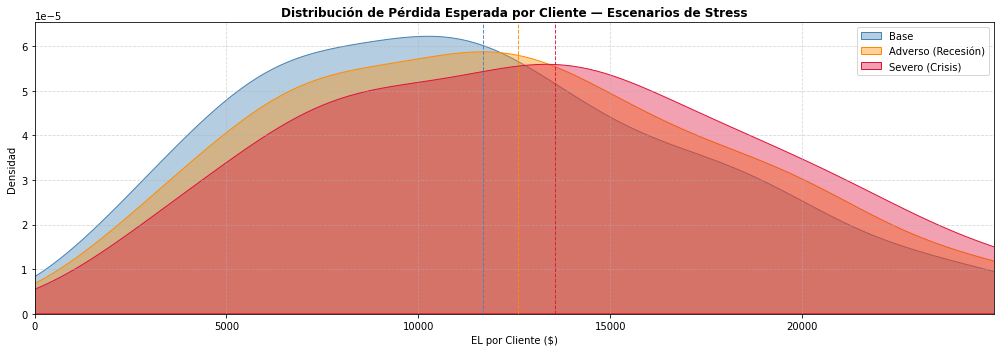

In [11]:
plt.figure(figsize=(14, 5))

for col, color, label in [
    ('EL_Base',    'steelblue',  'Base'),
    ('EL_Adverso', 'darkorange', 'Adverso (Recesión)'),
    ('EL_Severo',  'crimson',    'Severo (Crisis)')
]:
    sns.kdeplot(df[col], label=label, fill=True, color=color, alpha=0.4)
    plt.axvline(df[col].mean(), color=color, linestyle='--', linewidth=1, alpha=0.9)

plt.title('Distribución de Pérdida Esperada por Cliente — Escenarios de Stress', fontweight='bold')
plt.xlabel('EL por Cliente ($)')
plt.ylabel('Densidad')
plt.xlim(0, df['EL_Severo'].quantile(0.95))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 6. Distribución de PD: Base vs. Severo
Aísla el efecto del modelo sin ruido de EAD ni LGD.

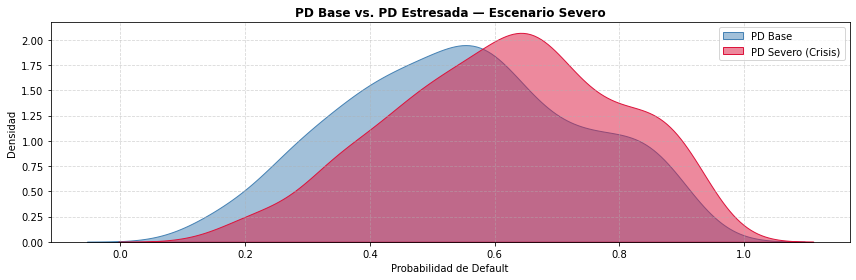

In [12]:
plt.figure(figsize=(12, 4))
sns.kdeplot(df['PD'],        label='PD Base',             fill=True, color='steelblue', alpha=0.5)
sns.kdeplot(df['PD_Severo'], label='PD Severo (Crisis)',   fill=True, color='crimson',  alpha=0.5)

plt.title('PD Base vs. PD Estresada — Escenario Severo', fontweight='bold')
plt.xlabel('Probabilidad de Default')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Concentración de la cartera — Curva de Lorenz
Muestra qué % de clientes genera qué % de la pérdida total. El coeficiente de Gini cuantifica la concentración (0 = perfectamente distribuida, 1 = un solo cliente genera todo).

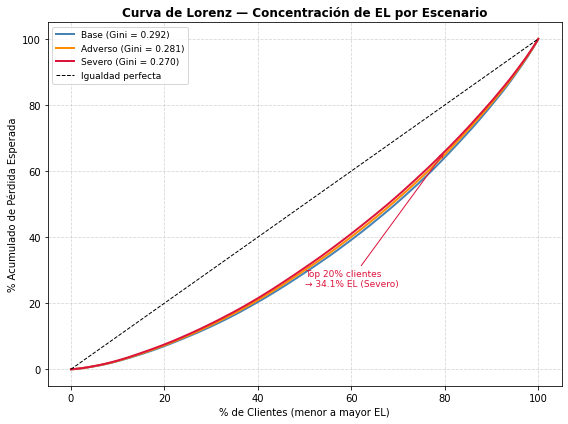

In [13]:
def lorenz(serie):
    s   = np.sort(serie)
    cum = np.cumsum(s) / s.sum()
    cum = np.insert(cum, 0, 0)
    pop = np.linspace(0, 1, len(cum))
    gini = 1 - 2 * np.trapz(cum, pop)
    return pop, cum, gini

fig, ax = plt.subplots(figsize=(8, 6))

for col, color, label in [
    ('EL_Base',    'steelblue',  'Base'),
    ('EL_Adverso', 'darkorange', 'Adverso'),
    ('EL_Severo',  'crimson',    'Severo')
]:
    pop, cum, gini = lorenz(df[col].values)
    ax.plot(pop * 100, cum * 100, color=color, linewidth=2,
            label=f'{label} (Gini = {gini:.3f})')

ax.plot([0, 100], [0, 100], 'k--', linewidth=1, label='Igualdad perfecta')

# Anotación: top 20% clientes -> % EL severo
pop_s, cum_s, _ = lorenz(df['EL_Severo'].values)
idx80  = int(0.80 * len(cum_s))
el_top20 = (1 - cum_s[idx80]) * 100
ax.annotate(f'Top 20% clientes\n→ {el_top20:.1f}% EL (Severo)',
            xy=(80, cum_s[idx80] * 100), xytext=(50, 25),
            arrowprops=dict(arrowstyle='->', color='crimson'),
            fontsize=9, color='crimson')

ax.set_xlabel('% de Clientes (menor a mayor EL)')
ax.set_ylabel('% Acumulado de Pérdida Esperada')
ax.set_title('Curva de Lorenz — Concentración de EL por Escenario', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Top 10% de clientes — mayor EL en escenario severo

In [14]:
n_top = max(1, int(len(df) * 0.10))
top10 = df.nlargest(n_top, 'EL_Severo')

conc_el  = top10['EL_Severo'].sum() / df['EL_Severo'].sum()
conc_ead = top10['EAD'].sum()        / df['EAD'].sum()

print(f"Top 10% clientes ({n_top:,} de {len(df):,}):")
print(f"  -> {conc_el:.1%} de la EL total (escenario severo)")
print(f"  -> {conc_ead:.1%} del EAD total")
print()
top10[['PD', 'LGD', 'EAD', 'PD_Severo', 'EL_Base', 'EL_Severo']].head(10).round(4)

Top 10% clientes (30 de 300):
  -> 18.9% de la EL total (escenario severo)
  -> 14.4% del EAD total



,PD,LGD,EAD,PD_Severo,EL_Base,EL_Severo
146,0.8644,0.45,81719.50,0.8991,31512.6945,33064.2675
235,0.7851,0.45,80164.00,0.8362,27933.2088,30166.0568
164,0.8606,0.45,73660.50,0.8961,28271.3170,29704.5191
101,0.7993,0.45,76102.50,0.8477,27022.8417,29031.3171
294,0.8666,0.45,69451.75,0.9008,26852.3428,28152.6503
13,0.7743,0.45,75189.25,0.8274,25821.8912,27996.7212
249,0.8466,0.45,69476.75,0.8853,26210.1828,27677.8323
112,0.6690,0.45,83119.00,0.7386,24500.7118,27626.6243
89,0.8303,0.45,67271.25,0.8724,24861.9899,26410.1222
96,0.7628,0.45,71565.00,0.8181,24196.7270,26345.3787


## 9. Análisis de sensibilidad — mapa de calor sobre los betas
Los betas son el supuesto más fuerte del modelo. Este análisis muestra cómo varía la EL total en el escenario severo al cambiar ambos coeficientes simultáneamente. La estrella marca los betas usados en el modelo.

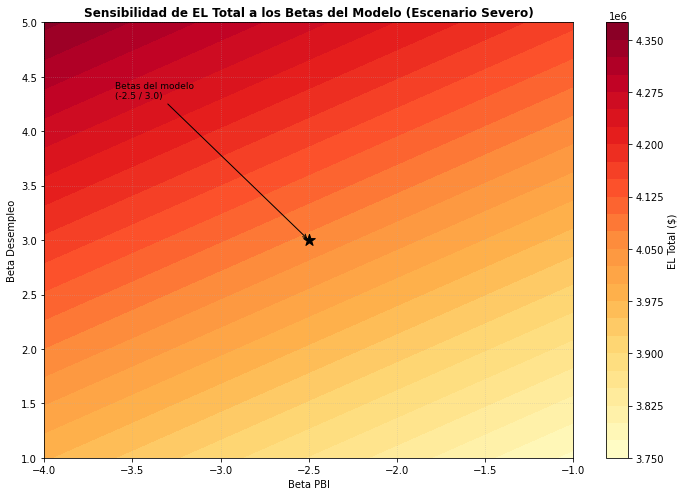

In [15]:
def el_total_betas(PD, LGD, EAD, beta_pbi, beta_des,
                   pbi_var=-0.05, des_actual=0.14, des_base=0.07):
    PD = np.clip(PD, 0.0001, 0.9999)
    logit = np.log(PD / (1 - PD))
    logit_s = logit + beta_pbi * pbi_var + beta_des * (des_actual - des_base)
    pd_s = 1 / (1 + np.exp(-logit_s))
    return (pd_s * LGD * EAD).sum()

beta_pbi_vals = np.linspace(-1.0, -4.0, 20)
beta_des_vals = np.linspace(1.0,   5.0, 20)
B_PBI, B_DES  = np.meshgrid(beta_pbi_vals, beta_des_vals)
EL_GRID = np.vectorize(
    lambda bp, bd: el_total_betas(df['PD'].values, df['LGD'].values, df['EAD'].values, bp, bd)
)(B_PBI, B_DES)

fig, ax = plt.subplots(figsize=(10, 7))
cp = ax.contourf(B_PBI, B_DES, EL_GRID, levels=25, cmap='YlOrRd')
plt.colorbar(cp, ax=ax, label='EL Total ($)')

ax.scatter([-2.5], [3.0], color='black', s=150, zorder=5, marker='*')
ax.annotate('Betas del modelo\n(-2.5 / 3.0)',
            xy=(-2.5, 3.0), xytext=(-3.6, 4.3),
            arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax.set_xlabel('Beta PBI')
ax.set_ylabel('Beta Desempleo')
ax.set_title('Sensibilidad de EL Total a los Betas del Modelo (Escenario Severo)', fontweight='bold')
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

## 10. Tabla de sensibilidad — beta_pbi

In [16]:
rows = []
for bp in [-1.5, -2.0, -2.5, -3.0, -3.5]:
    el = el_total_betas(df['PD'].values, df['LGD'].values, df['EAD'].values,
                        beta_pbi=bp, beta_des=3.0)
    rows.append({
        'beta_pbi': bp,
        'EL Total ($)': round(el, 2),
        'EL/EAD (%)':   round(el / ead_total * 100, 3),
        'Delta vs base (%)': round((el / el_base - 1) * 100, 2)
    })

pd.DataFrame(rows).set_index('beta_pbi')

,EL Total ($),EL/EAD (%),Delta vs base (%)
beta_pbi,,,
-1.5,3998616.18,26.994,13.94
-2.0,4033098.42,27.226,14.92
-2.5,4067449.37,27.458,15.90
-3.0,4101662.42,27.689,16.87
-3.5,4135731.03,27.919,17.84
